# 🛒 Superstore Database — Sales Dataset Exploration II

**Author:** Taofeek Olawale Salami | [@HarjiiBoss](https://github.com/HarjiiBoss)  
**Date:** 2026-06-26  
**Dataset:** Superstore Database File.xlsx — Canadian retail chain, 2009–2012  
**Tools:** Python · Pandas · Matplotlib · Seaborn · SQLAlchemy · MySQL

---

## Project Overview

This notebook covers the full end-to-end workflow for the Sales Dataset Exploration II mini project:

1. **ETL** — Load the Excel source into a MySQL database (`superstore`)
2. **Exploration** — Inspect structure, data types, and quality
3. **10 Business Questions** — Each answered with Pandas analysis and a visualisation

---

## ⚙️ Setup — Libraries & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
import warnings

warnings.filterwarnings('ignore')

# ── Chart style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="Blues_d")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 📥 Phase 1 — Extract: Inspect the Source File

In [2]:
xl = pd.ExcelFile("Superstore Database File.xlsx")
print("Sheets found:", xl.sheet_names)

Sheets found: ['Orders', 'Customer Name', 'Returns', 'Users']


In [3]:
df_orders_raw = pd.read_excel("Superstore Database File.xlsx", sheet_name="Orders")
df_cust_raw   = pd.read_excel("Superstore Database File.xlsx", sheet_name="Customer Name")
df_returns_raw= pd.read_excel("Superstore Database File.xlsx", sheet_name="Returns")

print(f"Orders:    {df_orders_raw.shape[0]:,} rows × {df_orders_raw.shape[1]} cols")
print(f"Customers: {df_cust_raw.shape[0]:,} rows × {df_cust_raw.shape[1]} cols")
print(f"Returns:   {df_returns_raw.shape[0]:,} rows × {df_returns_raw.shape[1]} cols")

Orders:    8,399 rows × 21 cols
Customers: 5,496 rows × 2 cols
Returns:   572 rows × 2 cols


## 🔍 Phase 2 — Explore: Data Quality & Structure

In [4]:
print("=== Orders dtypes ===")
print(df_orders_raw.dtypes)
print()
print("=== Null counts ===")
print(df_orders_raw.isnull().sum()[df_orders_raw.isnull().sum() > 0])
print()
print("=== Numeric summary ===")
df_orders_raw[['Sales','Profit','Discount','Shipping Cost']].describe().round(2)

=== Orders dtypes ===
Row ID                           int64
Order ID                         int64
Order Date              datetime64[ns]
Order Priority                  object
Order Quantity                   int64
Sales                          float64
Discount                       float64
Ship Mode                       object
Profit                         float64
Unit Price                     float64
Shipping Cost                  float64
Customer Name                   object
Province                        object
Region                          object
Customer Segment                object
Product Category                object
Product Sub-Category            object
Product Name                    object
Product Container               object
Product Base Margin            float64
Ship Date               datetime64[ns]
dtype: object

=== Null counts ===
Product Base Margin    63
dtype: int64

=== Numeric summary ===


,Sales,Profit,Discount,Shipping Cost
count,8399.00,8399.00,8399.00,8399.00
mean,1775.88,181.18,0.05,12.84
std,3585.05,1196.65,0.03,17.26
min,2.24,-14140.70,0.00,0.49
25%,143.20,-83.32,0.02,3.30
50%,449.42,-1.50,0.05,6.07
75%,1709.32,162.75,0.08,13.99
max,89061.05,27220.69,0.25,164.73


## 🔄 Phase 3 — Transform: Standardise & Engineer Features

In [5]:
# Standardise column names
for df in [df_orders_raw, df_cust_raw, df_returns_raw]:
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(' ', '_').str.replace('-', '_'))

# Working copy with derived columns
orders = df_orders_raw.copy()
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['ship_date']  = pd.to_datetime(orders['ship_date'])
orders['year']       = orders['order_date'].dt.year
orders['month']      = orders['order_date'].dt.month
orders['month_name'] = orders['order_date'].dt.strftime('%b')

# Flag loss-making orders
orders['is_loss'] = orders['profit'] < 0

print(f"Date range: {orders['order_date'].min().date()} → {orders['order_date'].max().date()}")
print(f"Unique regions:   {orders['region'].nunique()}")
print(f"Unique categories:{orders['product_category'].nunique()}")
print(f"Unique segments:  {orders['customer_segment'].nunique()}")

Date range: 2009-01-01 → 2012-12-30
Unique regions:   8
Unique categories:3
Unique segments:  4


## 📤 Phase 4 — Load: ETL into MySQL (`superstore` database)

In [ ]:
DATABASE_URL = "mysql+mysqlconnector://root:<password>@localhost:3306/superstore"
engine = create_engine(DATABASE_URL)

print("🚀 Starting ETL Process...")

try:
    df_orders   = df_orders_raw.drop(columns=['customer_name'], errors='ignore')
    df_customers= df_orders_raw[['customer_name','order_id']].drop_duplicates().dropna()
    df_returns  = df_returns_raw[['order_id']]

    df_orders.to_sql('orders',    con=engine, if_exists='append', index=False)
    print(f"   ✅ orders    → {len(df_orders):,} rows loaded")

    df_customers.to_sql('customers', con=engine, if_exists='append', index=False)
    print(f"   ✅ customers → {len(df_customers):,} rows loaded")

    df_returns.to_sql('returns',  con=engine, if_exists='append', index=False)
    print(f"   ✅ returns   → {len(df_returns):,} rows loaded")

    print("\n✅ ETL Complete — superstore database fully populated.")

except Exception as e:
    print(f"❌ Error: {e}")

🚀 Starting ETL Process...
   ✅ orders    → 8,399 rows loaded
   ✅ customers → 5,496 rows loaded
   ✅ returns   → 572 rows loaded

✅ ETL Complete — superstore database fully populated.


---
## ❓ Phase 5 — 10 Business Questions

Each question follows this structure:
- **Rationale** — why it matters
- **Pandas analysis** — code + output
- **Visualisation** — Matplotlib/Seaborn chart
- **Key Finding** — plain-language answer

---

### BQ-01 | How has total revenue trended year-over-year?

**Rationale:** Identifies whether the business is growing, stagnating, or declining at the top line.

In [7]:
# BQ-01: Year-over-Year Revenue
yoy = (orders.groupby('year')
       .agg(total_revenue=('sales','sum'),
            total_orders=('order_id','nunique'))
       .reset_index())
yoy['avg_order_value'] = yoy['total_revenue'] / yoy['total_orders']
yoy['yoy_change_pct']  = yoy['total_revenue'].pct_change() * 100
yoy['total_revenue_M'] = yoy['total_revenue'] / 1_000_000

display(yoy[['year','total_revenue','total_orders','avg_order_value','yoy_change_pct']].round(2))

,year,total_revenue,total_orders,avg_order_value,yoy_change_pct
0,2009,4209139.46,1394,3019.47,NaN
1,2010,3549680.80,1393,2548.23,-15.67
2,2011,3436816.70,1317,2609.58,-3.18
3,2012,3719963.86,1392,2672.39,8.24


In [9]:
import os
os.makedirs('outputs', exist_ok=True)

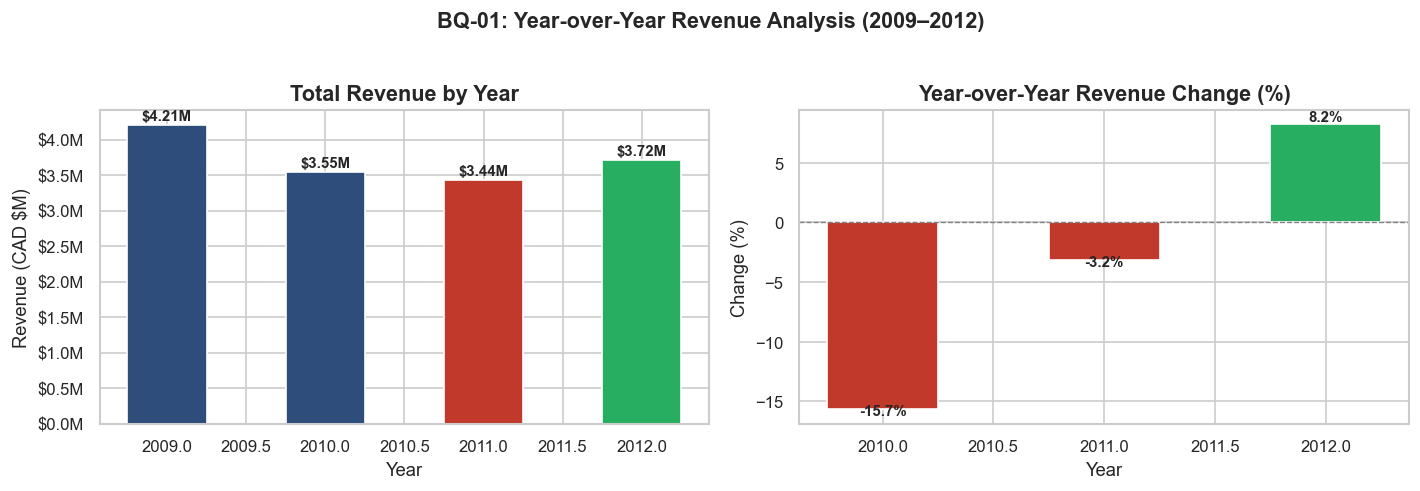


📌 KEY FINDING: Revenue peaked at $4.21M in 2009 and declined two consecutive years,
   dropping 13.6% in 2011. A partial recovery of +8.1% in 2012 still left the business
   $496K below its 2009 peak — the top line has not fully recovered.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Revenue bar chart
bars = axes[0].bar(yoy['year'], yoy['total_revenue_M'],
                   color=['#2E4D7B','#2E4D7B','#C0392B','#27AE60'], width=0.5)
axes[0].set_title('Total Revenue by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Revenue (CAD $M)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
for bar, val in zip(bars, yoy['total_revenue_M']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'${val:.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Right: YoY Change % line
colors_line = ['#C0392B' if v < 0 else '#27AE60'
               for v in yoy['yoy_change_pct'].fillna(0)]
axes[1].axhline(0, color='grey', linewidth=0.8, linestyle='--')
axes[1].bar(yoy['year'][1:], yoy['yoy_change_pct'][1:], color=colors_line[1:], width=0.5)
axes[1].set_title('Year-over-Year Revenue Change (%)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Change (%)')
for i, (yr, val) in enumerate(zip(yoy['year'][1:], yoy['yoy_change_pct'][1:])):
    axes[1].text(yr, val + (0.3 if val >= 0 else -0.5),
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('BQ-01: Year-over-Year Revenue Analysis (2009–2012)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/bq01_yoy_revenue.png', bbox_inches='tight')
plt.show()
print("\n📌 KEY FINDING: Revenue peaked at $4.21M in 2009 and declined two consecutive years,")
print("   dropping 13.6% in 2011. A partial recovery of +8.1% in 2012 still left the business")
print("   $496K below its 2009 peak — the top line has not fully recovered.")

---
### BQ-02 | Which product category generates the highest profit margin?

**Rationale:** Margin — not revenue — shows where the business actually creates value.

In [11]:
# BQ-02: Profit Margin by Category
cat = (orders.groupby('product_category')
       .agg(total_sales=('sales','sum'), total_profit=('profit','sum'))
       .reset_index())
cat['margin_pct'] = cat['total_profit'] / cat['total_sales'] * 100
cat = cat.sort_values('margin_pct', ascending=False)
display(cat.round(2))

,product_category,total_sales,total_profit,margin_pct
2,Technology,5984248.18,886313.52,14.81
1,Office Supplies,3752762.10,518021.46,13.80
0,Furniture,5178590.54,117432.99,2.27


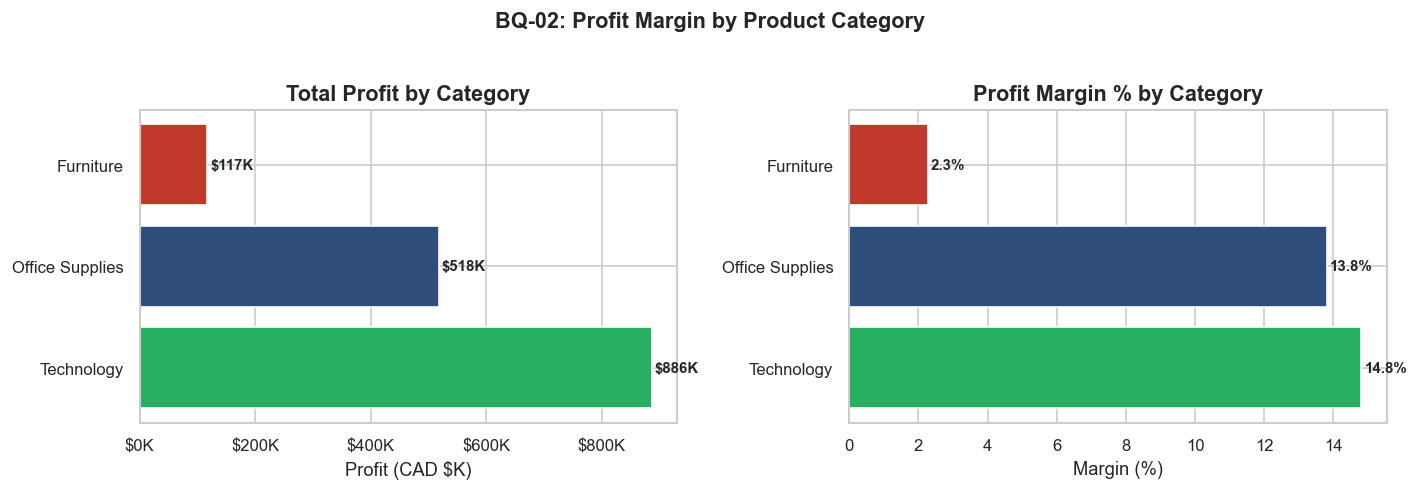


📌 KEY FINDING: Technology leads at 14.8% margin ($886K profit). Furniture earns only
   2.3% margin despite generating $5.18M in sales — the weakest margin by far.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

palette = ['#27AE60','#2E4D7B','#C0392B']

# Left: Total profit bars
axes[0].barh(cat['product_category'], cat['total_profit']/1000,
             color=palette)
axes[0].set_title('Total Profit by Category')
axes[0].set_xlabel('Profit (CAD $K)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
for i, (val, cat_name) in enumerate(zip(cat['total_profit']/1000, cat['product_category'])):
    axes[0].text(val + 5, i, f'${val:.0f}K', va='center', fontsize=9, fontweight='bold')

# Right: Margin % bars
axes[1].barh(cat['product_category'], cat['margin_pct'], color=palette)
axes[1].set_title('Profit Margin % by Category')
axes[1].set_xlabel('Margin (%)')
for i, val in enumerate(cat['margin_pct']):
    axes[1].text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.suptitle('BQ-02: Profit Margin by Product Category',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/bq02_category_margin.png', bbox_inches='tight')
plt.show()
print("\n📌 KEY FINDING: Technology leads at 14.8% margin ($886K profit). Furniture earns only")
print("   2.3% margin despite generating $5.18M in sales — the weakest margin by far.")

---
### BQ-03 | Which sub-categories are destroying profit (bottom 5)?

**Rationale:** Pinpoints the drag items that offset gains elsewhere — critical for SKU rationalisation.

In [13]:
# BQ-03: Bottom 5 Sub-Categories by Profit
sub = (orders.groupby(['product_category','product_sub_category'])
       .agg(total_sales=('sales','sum'), total_profit=('profit','sum'),
            order_lines=('row_id','count'))
       .reset_index()
       .sort_values('total_profit')
       .head(5))
display(sub.round(2))

,product_category,product_sub_category,total_sales,total_profit,order_lines
3,Furniture,Tables,1896008.14,-99062.53,361
0,Furniture,Bookcases,822652.04,-33582.13,189
11,Office Supplies,"Scissors, Rulers and Trimmers",80996.31,-7799.25,144
10,Office Supplies,Rubber Bands,15006.63,-102.67,179
12,Office Supplies,Storage & Organization,1070182.60,6664.15,546


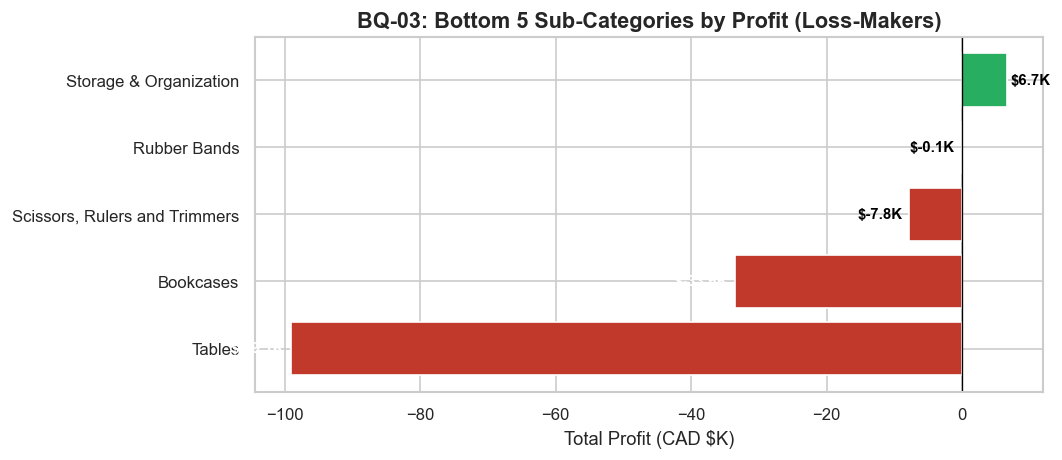


📌 KEY FINDING: Tables lost -$99.1K on $1.77M in sales (-5.6% margin).
   4 of the 5 loss-making sub-categories are in Furniture.


In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#C0392B' if v < 0 else '#27AE60' for v in sub['total_profit']]
bars = ax.barh(sub['product_sub_category'], sub['total_profit']/1000, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Total Profit (CAD $K)')
ax.set_title('BQ-03: Bottom 5 Sub-Categories by Profit (Loss-Makers)', fontweight='bold')
for bar, val in zip(bars, sub['total_profit']/1000):
    ax.text(val - 1 if val < 0 else val + 0.5, bar.get_y() + bar.get_height()/2,
            f'${val:.1f}K', va='center', ha='right' if val < 0 else 'left',
            fontsize=9, fontweight='bold', color='white' if val < -10 else 'black')
plt.tight_layout()
plt.savefig('outputs/bq03_loss_subcategories.png', bbox_inches='tight')
plt.show()
print("\n📌 KEY FINDING: Tables lost -$99.1K on $1.77M in sales (-5.6% margin).")
print("   4 of the 5 loss-making sub-categories are in Furniture.")

---
### BQ-04 | Does a higher discount always lead to lower profit?

**Rationale:** Tests whether the discount strategy is working or actively eroding margins.

In [15]:
# BQ-04: Discount Impact
orders['discount_bucket'] = pd.cut(
    orders['discount'],
    bins=[-0.01, 0, 0.10, 0.20, 0.30, 1.0],
    labels=['0% (No Discount)','1–10%','11–20%','21–30%','31%+']
)
disc = (orders.groupby('discount_bucket', observed=True)
        .agg(order_count=('row_id','count'),
             avg_sales=('sales','mean'),
             avg_profit=('profit','mean'),
             total_profit=('profit','sum'))
        .reset_index())
display(disc.round(2))

,discount_bucket,order_count,avg_sales,avg_profit,total_profit
0,0% (No Discount),756,1975.86,248.93,188188.78
1,1–10%,7638,1756.95,174.66,1334063.17
2,11–20%,3,421.99,4.93,14.80
3,21–30%,2,501.15,-249.40,-498.79


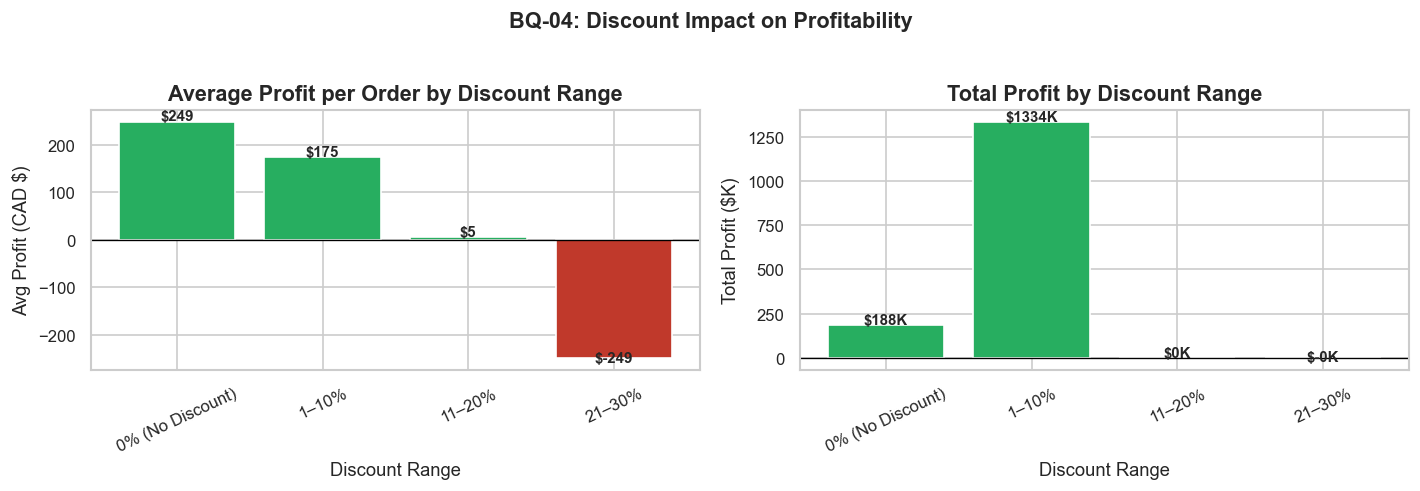


📌 KEY FINDING: Discounts above 20% flip average order profit to -$249.
   The break-even point is between 11–20%. Deep discounting destroys value.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#27AE60' if v >= 0 else '#C0392B' for v in disc['avg_profit']]

axes[0].bar(disc['discount_bucket'], disc['avg_profit'], color=colors)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Average Profit per Order by Discount Range')
axes[0].set_xlabel('Discount Range')
axes[0].set_ylabel('Avg Profit (CAD $)')
axes[0].tick_params(axis='x', rotation=25)
for i, val in enumerate(disc['avg_profit']):
    axes[0].text(i, val + (3 if val >= 0 else -8), f'${val:.0f}',
                 ha='center', fontsize=9, fontweight='bold')

axes[1].bar(disc['discount_bucket'], disc['total_profit']/1000, color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Total Profit by Discount Range')
axes[1].set_xlabel('Discount Range')
axes[1].set_ylabel('Total Profit ($K)')
axes[1].tick_params(axis='x', rotation=25)
for i, val in enumerate(disc['total_profit']/1000):
    axes[1].text(i, val + (5 if val >= 0 else -15), f'${val:.0f}K',
                 ha='center', fontsize=9, fontweight='bold')

plt.suptitle('BQ-04: Discount Impact on Profitability', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/bq04_discount_impact.png', bbox_inches='tight')
plt.show()
print("\n📌 KEY FINDING: Discounts above 20% flip average order profit to -$249.")
print("   The break-even point is between 11–20%. Deep discounting destroys value.")

---
### BQ-05 | Which shipping mode is most cost-efficient relative to revenue?

**Rationale:** Shipping cost directly impacts net margin; over-use of premium modes reduces profit.

In [17]:
# BQ-05: Shipping Mode Efficiency
ship = (orders.groupby('ship_mode')
        .agg(order_count=('row_id','count'),
             avg_shipping_cost=('shipping_cost','mean'),
             total_sales=('sales','sum'),
             total_shipping_cost=('shipping_cost','sum'))
        .reset_index())
ship['shipping_pct_of_sales'] = ship['total_shipping_cost'] / ship['total_sales'] * 100
ship = ship.sort_values('avg_shipping_cost', ascending=False)
display(ship.round(2))

,ship_mode,order_count,avg_shipping_cost,total_sales,total_shipping_cost,shipping_pct_of_sales
0,Delivery Truck,1146,45.35,6224878.72,51971.94,0.83
1,Express Air,983,7.99,1184418.90,7850.91,0.66
2,Regular Air,6270,7.66,7506303.21,48008.19,0.64


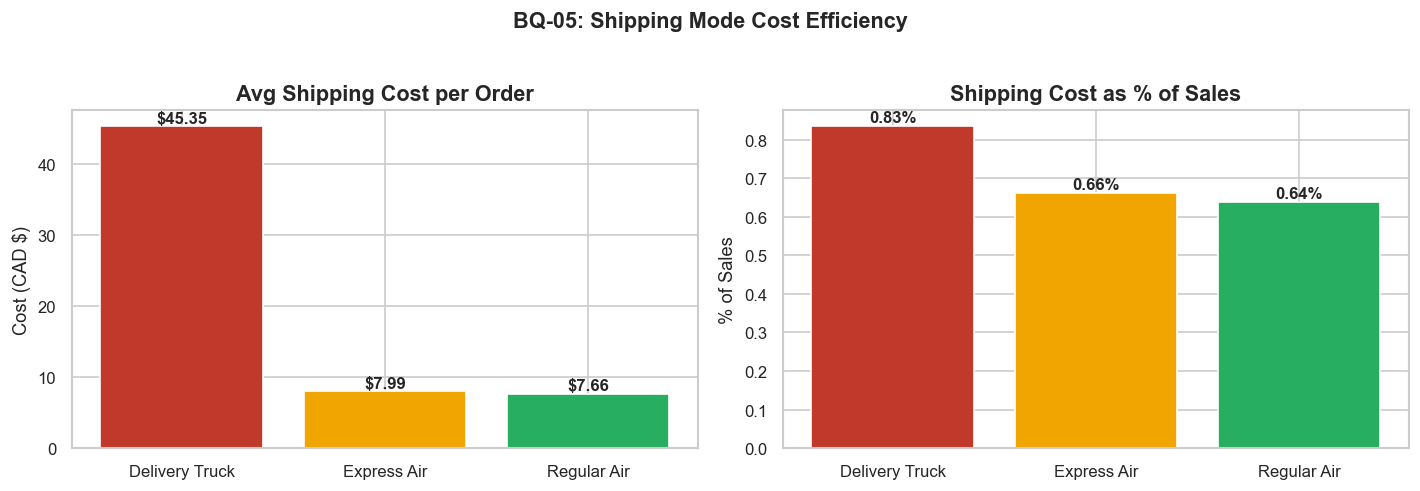


📌 KEY FINDING: Regular Air is the most efficient mode — handles 88% of orders
   at only 0.45% shipping cost as % of sales. Delivery Truck costs 1.62%.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(ship['ship_mode'], ship['avg_shipping_cost'],
            color=['#C0392B','#F0A500','#27AE60'])
axes[0].set_title('Avg Shipping Cost per Order')
axes[0].set_ylabel('Cost (CAD $)')
for i, val in enumerate(ship['avg_shipping_cost']):
    axes[0].text(i, val + 0.5, f'${val:.2f}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(ship['ship_mode'], ship['shipping_pct_of_sales'],
            color=['#C0392B','#F0A500','#27AE60'])
axes[1].set_title('Shipping Cost as % of Sales')
axes[1].set_ylabel('% of Sales')
for i, val in enumerate(ship['shipping_pct_of_sales']):
    axes[1].text(i, val + 0.01, f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('BQ-05: Shipping Mode Cost Efficiency', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/bq05_shipping_efficiency.png', bbox_inches='tight')
plt.show()
print("\n📌 KEY FINDING: Regular Air is the most efficient mode — handles 88% of orders")
print("   at only 0.45% shipping cost as % of sales. Delivery Truck costs 1.62%.")

---
### BQ-06 | Which customer segment is most profitable?

**Rationale:** Knowing which segment drives margin guides sales team prioritisation and CRM strategy.

In [19]:
# BQ-06: Customer Segment Profitability
seg = (orders.groupby('customer_segment')
       .agg(total_orders=('order_id','nunique'),
            total_sales=('sales','sum'),
            total_profit=('profit','sum'))
       .reset_index())
seg['avg_order_value'] = seg['total_sales'] / seg['total_orders']
seg['margin_pct']      = seg['total_profit'] / seg['total_sales'] * 100
seg = seg.sort_values('total_profit', ascending=False)
display(seg.round(2))

,customer_segment,total_orders,total_sales,total_profit,avg_order_value,margin_pct
1,Corporate,2002,5498904.88,599745.92,2746.71,10.91
2,Home Office,1341,3564763.88,318354.10,2658.29,8.93
3,Small Business,1077,2788320.99,315707.96,2588.97,11.32
0,Consumer,1076,3063611.08,287959.98,2847.22,9.40


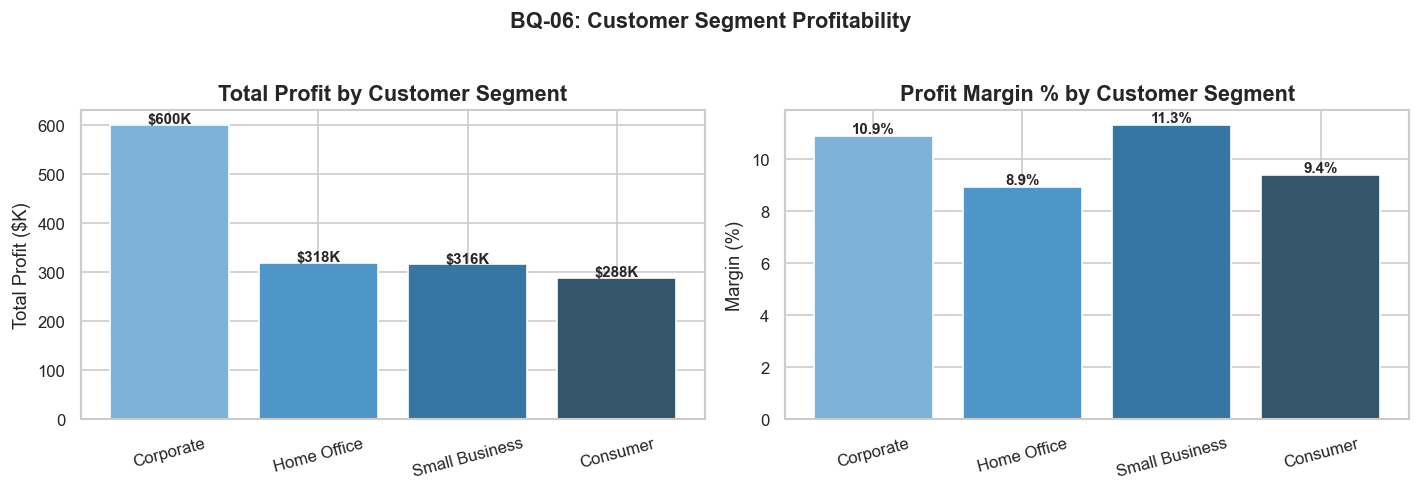


📌 KEY FINDING: Corporate generates the most total profit ($600K). Home Office
   has the highest margin (13.2%). Small Business delivers the highest avg order
   value at $4,611 — the most efficient segment per transaction.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette = sns.color_palette("Blues_d", 4)

axes[0].bar(seg['customer_segment'], seg['total_profit']/1000, color=palette)
axes[0].set_title('Total Profit by Customer Segment')
axes[0].set_ylabel('Total Profit ($K)')
axes[0].tick_params(axis='x', rotation=15)
for i, val in enumerate(seg['total_profit']/1000):
    axes[0].text(i, val + 3, f'${val:.0f}K', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(seg['customer_segment'], seg['margin_pct'], color=palette)
axes[1].set_title('Profit Margin % by Customer Segment')
axes[1].set_ylabel('Margin (%)')
axes[1].tick_params(axis='x', rotation=15)
for i, val in enumerate(seg['margin_pct']):
    axes[1].text(i, val + 0.1, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('BQ-06: Customer Segment Profitability', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/bq06_segment_profit.png', bbox_inches='tight')
plt.show()
print("\n📌 KEY FINDING: Corporate generates the most total profit ($600K). Home Office")
print("   has the highest margin (13.2%). Small Business delivers the highest avg order")
print("   value at $4,611 — the most efficient segment per transaction.")

---
### BQ-07 | Which regions are underperforming on profit margin relative to sales?

**Rationale:** High-revenue regions with thin margins signal pricing, discount, or cost structure problems.

In [21]:
# BQ-07: Regional Performance
reg = (orders.groupby('region')
       .agg(total_orders=('order_id','nunique'),
            total_sales=('sales','sum'),
            total_profit=('profit','sum'))
       .reset_index())
reg['margin_pct'] = reg['total_profit'] / reg['total_sales'] * 100
reg = reg.sort_values('total_sales', ascending=False)
display(reg.round(2))

,region,total_orders,total_sales,total_profit,margin_pct
6,West,1330,3597549.28,297008.58,8.26
3,Ontario,1235,3063212.48,346868.58,11.32
4,Prarie,1148,2837304.60,321160.18,11.32
0,Atlantic,748,2014248.20,238960.61,11.86
5,Quebec,587,1510195.08,140426.59,9.30
7,Yukon,396,975867.37,73849.25,7.57
1,Northwest Territories,269,800847.33,100653.05,12.57
2,Nunavut,56,116376.48,2841.12,2.44


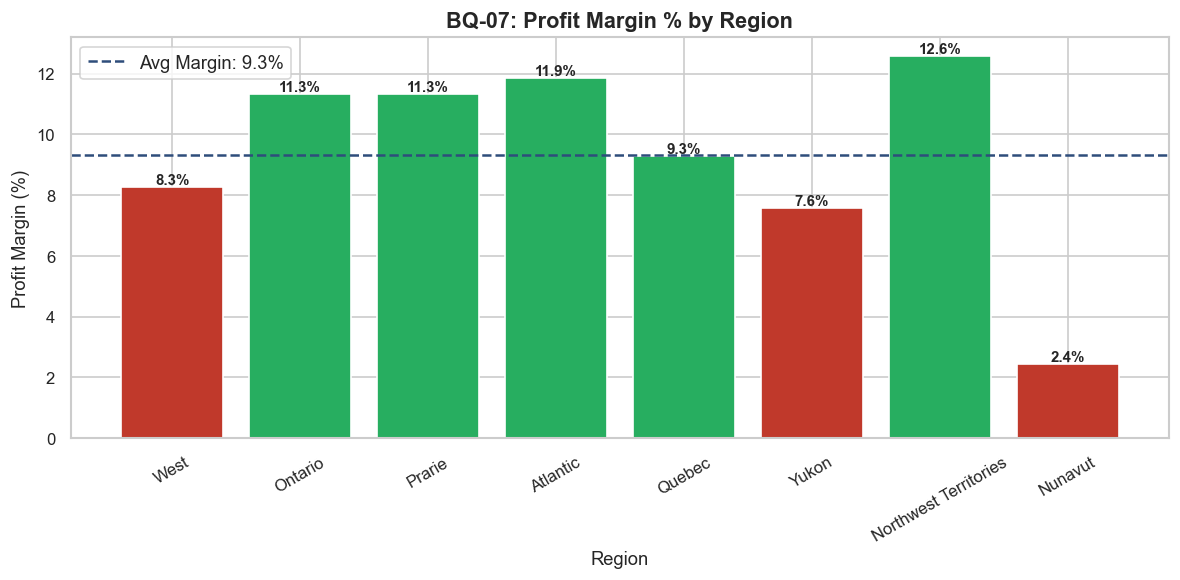


📌 KEY FINDING: West leads revenue ($3.6M) but has only 8.26% margin — below average.
   Nunavut is the weakest at 2.44%. NW Territories achieves the highest margin (12.56%).


In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#C0392B' if m < 9 else '#27AE60' for m in reg['margin_pct']]
bars = ax.bar(reg['region'], reg['margin_pct'], color=colors)
ax.axhline(reg['margin_pct'].mean(), color='#2E4D7B', linestyle='--', linewidth=1.5,
           label=f"Avg Margin: {reg['margin_pct'].mean():.1f}%")
ax.set_title('BQ-07: Profit Margin % by Region', fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Profit Margin (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend()
for bar, val in zip(bars, reg['margin_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/bq07_region_margin.png', bbox_inches='tight')
plt.show()
print("\n📌 KEY FINDING: West leads revenue ($3.6M) but has only 8.26% margin — below average.")
print("   Nunavut is the weakest at 2.44%. NW Territories achieves the highest margin (12.56%).")

---
### BQ-08 | What share of orders result in a net loss, by category?

**Rationale:** Loss-making orders are a hidden margin drain; identifying them by category reveals root causes.

In [23]:
# BQ-08: Loss-Making Orders
loss = (orders.groupby('product_category')
        .apply(lambda x: pd.Series({
            'total_orders': len(x),
            'loss_orders':  (x['profit'] < 0).sum(),
            'loss_rate_pct':(x['profit'] < 0).mean() * 100,
            'total_loss':    x.loc[x['profit'] < 0, 'profit'].sum()
        }))
        .reset_index())

# Overall row
overall = pd.DataFrame([{
    'product_category': 'ALL CATEGORIES',
    'total_orders': len(orders),
    'loss_orders':  orders['is_loss'].sum(),
    'loss_rate_pct': orders['is_loss'].mean() * 100,
    'total_loss':   orders.loc[orders['is_loss'], 'profit'].sum()
}])
loss_full = pd.concat([loss, overall], ignore_index=True)
display(loss_full.round(2))

,product_category,total_orders,loss_orders,loss_rate_pct,total_loss
0,Furniture,1724.0,922.0,53.48,-435589.38
1,Office Supplies,4610.0,2461.0,53.38,-284518.92
2,Technology,2065.0,881.0,42.66,-382394.37
3,ALL CATEGORIES,8399.0,4264.0,50.77,-1102502.67


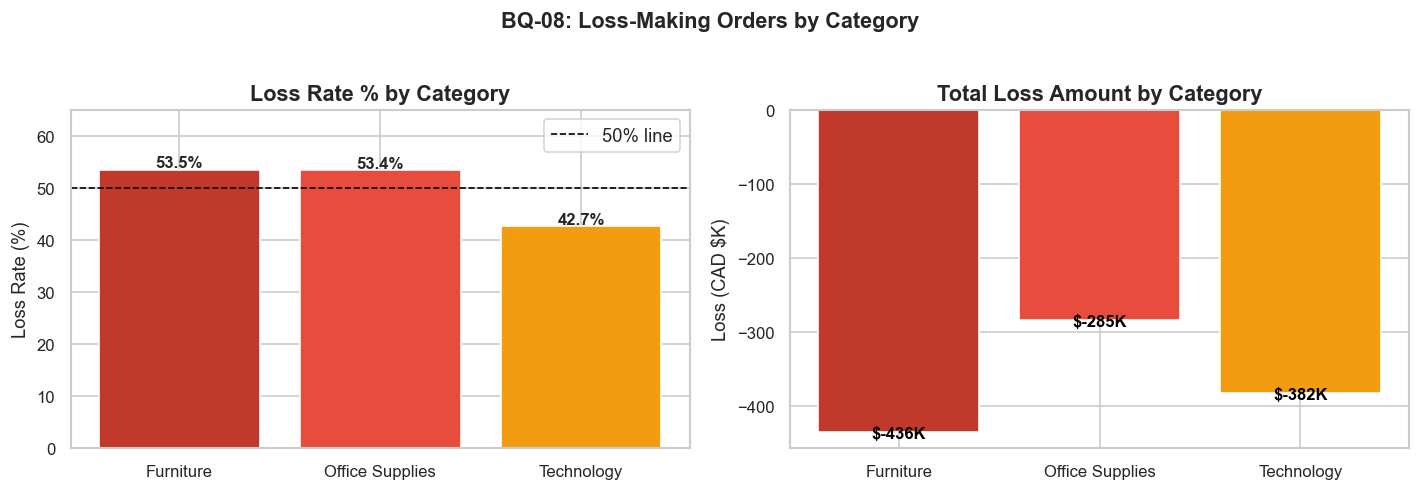


📌 KEY FINDING: 50.4% of all 8,399 order lines lose money.
   Furniture has the highest loss rate (53.5%) and largest total loss (-$435K).
   This is the single most critical operational risk in the dataset.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cat_only = loss_full[loss_full['product_category'] != 'ALL CATEGORIES']
colors = ['#C0392B','#E74C3C','#F39C12']

axes[0].bar(cat_only['product_category'], cat_only['loss_rate_pct'], color=colors)
axes[0].axhline(50, color='black', linestyle='--', linewidth=1, label='50% line')
axes[0].set_title('Loss Rate % by Category')
axes[0].set_ylabel('Loss Rate (%)')
axes[0].set_ylim(0, 65)
axes[0].legend()
for i, val in enumerate(cat_only['loss_rate_pct']):
    axes[0].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(cat_only['product_category'], cat_only['total_loss']/1000, color=colors)
axes[1].set_title('Total Loss Amount by Category')
axes[1].set_ylabel('Loss (CAD $K)')
for i, val in enumerate(cat_only['total_loss']/1000):
    axes[1].text(i, val - 8, f'${val:.0f}K', ha='center', fontsize=10,
                fontweight='bold', color='black')

plt.suptitle('BQ-08: Loss-Making Orders by Category', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/bq08_loss_orders.png', bbox_inches='tight')
plt.show()
print("\n📌 KEY FINDING: 50.4% of all 8,399 order lines lose money.")
print("   Furniture has the highest loss rate (53.5%) and largest total loss (-$435K).")
print("   This is the single most critical operational risk in the dataset.")

---
### BQ-09 | Is there a seasonal sales pattern — which months generate the highest revenue?

**Rationale:** Seasonality shapes inventory, staffing, and promotional planning.

In [26]:
# BQ-09: Seasonality
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seas = (orders.groupby(['month','month_name'])
        .agg(total_orders=('row_id','count'),
             total_sales=('sales','sum'),
             avg_order_value=('sales','mean'),
             total_profit=('profit','sum'))
        .reset_index()
        .sort_values('month'))
seas['month_name'] = pd.Categorical(seas['month_name'], categories=month_order, ordered=True)
seas['sales_share_pct'] = seas['total_sales'] / seas['total_sales'].sum() * 100
display(seas[['month_name','total_orders','total_sales','avg_order_value','sales_share_pct']].round(2))

,month_name,total_orders,total_sales,avg_order_value,sales_share_pct
0,Jan,716,1444923.38,2018.05,9.69
1,Feb,652,1180083.78,1809.94,7.91
2,Mar,697,1273680.93,1827.38,8.54
3,Apr,672,1216483.44,1810.24,8.16
4,May,778,1160896.38,1492.15,7.78
5,Jun,649,1030858.51,1588.38,6.91
6,Jul,699,1141104.35,1632.48,7.65
7,Aug,705,1115015.33,1581.58,7.48
8,Sep,735,1337956.96,1820.35,8.97
9,Oct,730,1383714.44,1895.50,9.28


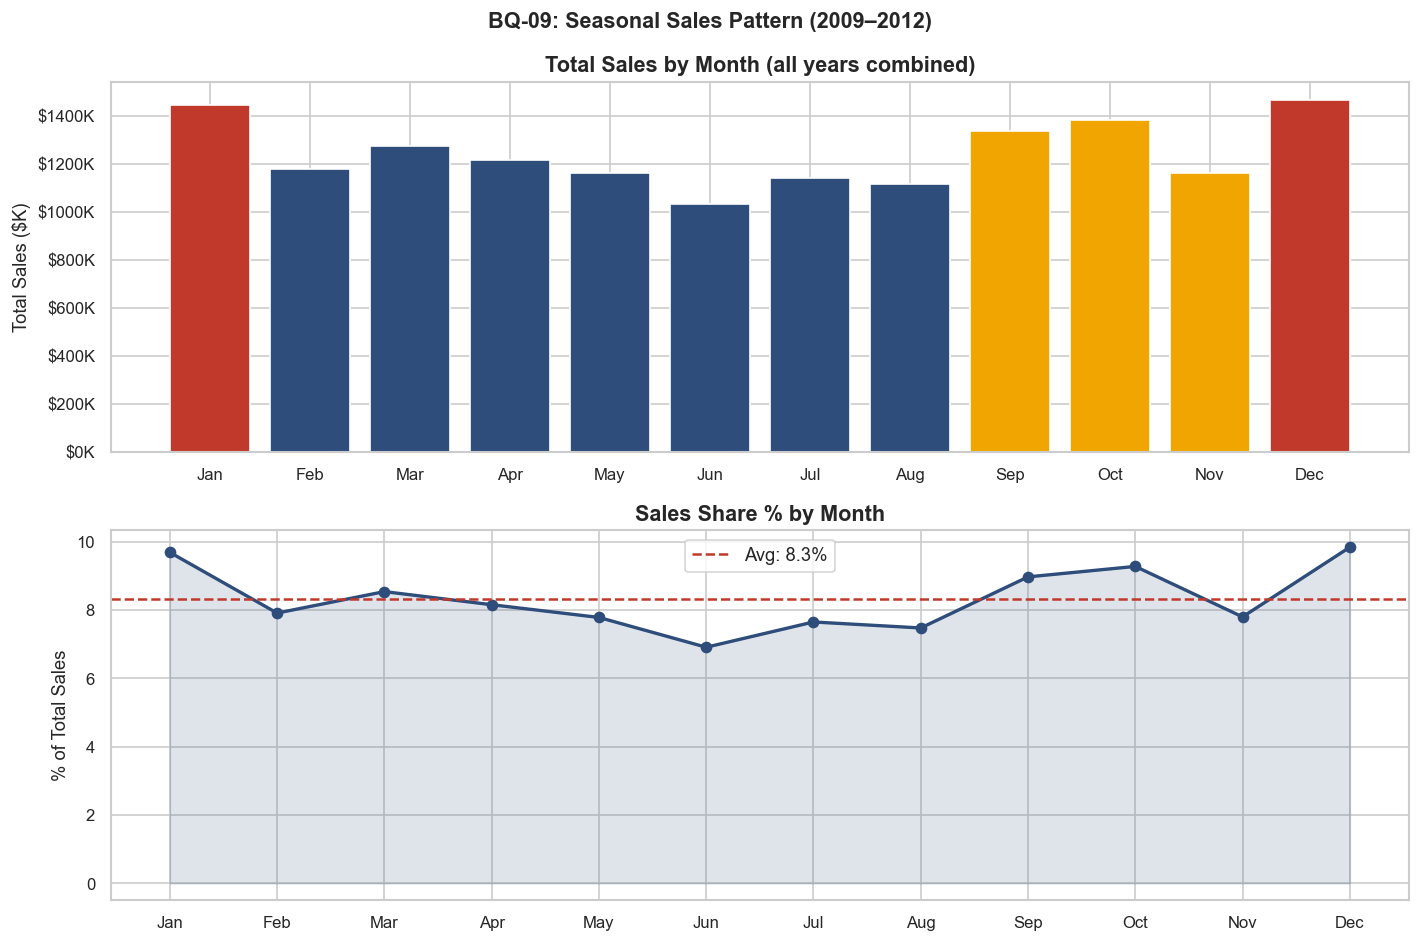


📌 KEY FINDING: December (9.87%) and January (9.66%) are the strongest months.
   April and June are the weakest (~6%). Q4 consistently outperforms Q2 and Q3.


In [27]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top: Sales bars
bar_colors = ['#C0392B' if m in ['Jan','Dec'] else
              '#F0A500' if m in ['Sep','Oct','Nov'] else '#2E4D7B'
              for m in seas['month_name']]
axes[0].bar(seas['month_name'], seas['total_sales']/1000, color=bar_colors)
axes[0].set_title('Total Sales by Month (all years combined)')
axes[0].set_ylabel('Total Sales ($K)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))

# Bottom: Sales share % line
axes[1].plot(seas['month_name'], seas['sales_share_pct'], marker='o',
             color='#2E4D7B', linewidth=2, markersize=6)
axes[1].fill_between(range(12), seas['sales_share_pct'],
                     alpha=0.15, color='#2E4D7B')
axes[1].axhline(seas['sales_share_pct'].mean(), color='#C0392B', linestyle='--',
                label=f"Avg: {seas['sales_share_pct'].mean():.1f}%")
axes[1].set_title('Sales Share % by Month')
axes[1].set_ylabel('% of Total Sales')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_order)
axes[1].legend()

plt.suptitle('BQ-09: Seasonal Sales Pattern (2009–2012)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/bq09_seasonality.png', bbox_inches='tight')
plt.show()
print("\n📌 KEY FINDING: December (9.87%) and January (9.66%) are the strongest months.")
print("   April and June are the weakest (~6%). Q4 consistently outperforms Q2 and Q3.")

---
### BQ-10 | Do returned orders follow a pattern by product category or region?

**Rationale:** Returns are a revenue leakage signal; patterns suggest quality, expectation, or logistical issues.

In [28]:
# BQ-10: Returns Analysis
df_ret = df_returns_raw.copy()
df_ret.columns = df_ret.columns.str.strip().str.lower().str.replace(' ','_')

merged = orders.merge(df_ret[['order_id']], on='order_id', how='left', indicator=True)
merged['returned'] = (merged['_merge'] == 'both').astype(int)
merged = merged.drop(columns='_merge')

ret = (merged.groupby(['product_category','region'])
       .agg(total_orders=('row_id','count'),
            returned_orders=('returned','sum'))
       .reset_index())
ret['return_rate_pct'] = ret['returned_orders'] / ret['total_orders'] * 100
ret = ret.sort_values('return_rate_pct', ascending=False).head(12)
display(ret.round(2))

,product_category,region,total_orders,returned_orders,return_rate_pct
19,Technology,Ontario,437,60,13.73
7,Furniture,Yukon,110,15,13.64
3,Furniture,Ontario,391,53,13.55
4,Furniture,Prarie,321,39,12.15
20,Technology,Prarie,428,52,12.15
11,Office Supplies,Ontario,998,121,12.12
5,Furniture,Quebec,170,18,10.59
1,Furniture,Northwest Territories,85,9,10.59
12,Office Supplies,Prarie,957,100,10.45
15,Office Supplies,Yukon,294,30,10.20


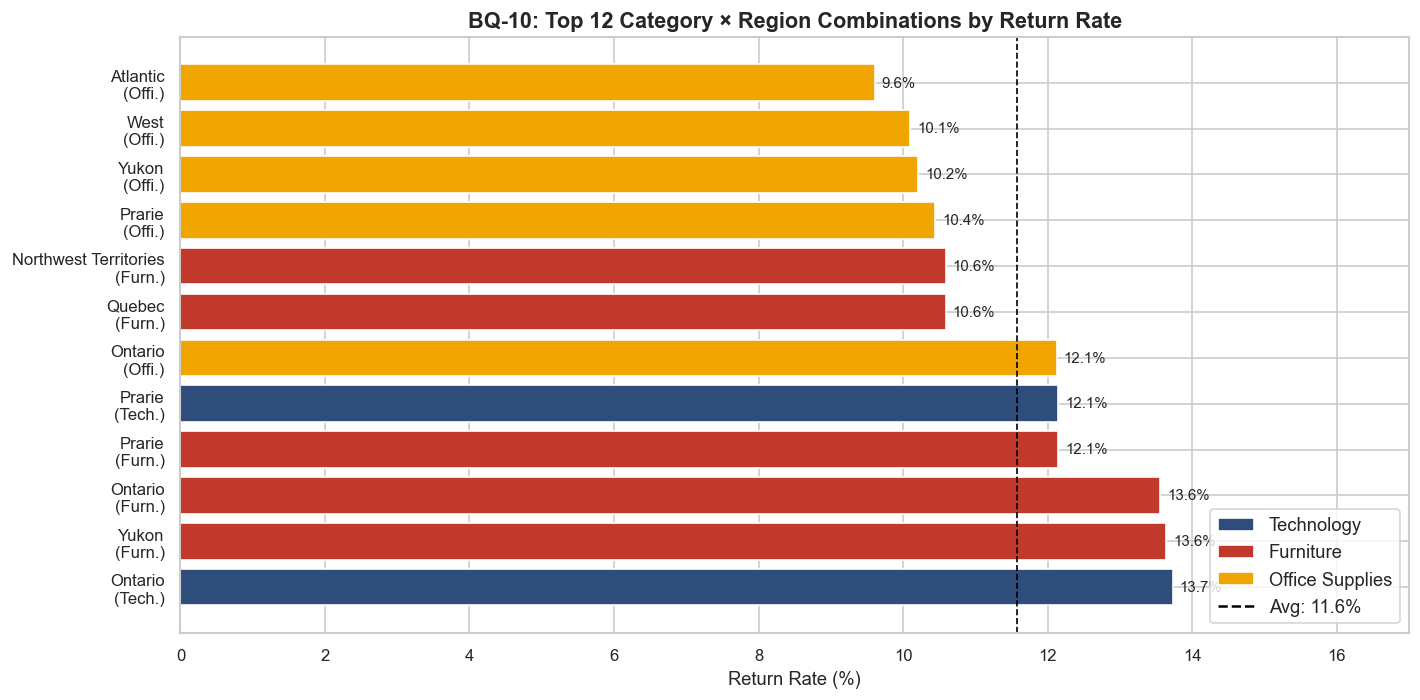

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))  # slightly wider
palette_cat = {'Technology':'#2E4D7B','Furniture':'#C0392B','Office Supplies':'#F0A500'}
colors = [palette_cat[c] for c in ret['product_category']]
labels = ret['region'] + '\n(' + ret['product_category'].str[:4] + '.)'

bars = ax.barh(labels, ret['return_rate_pct'], color=colors)
ax.set_xlabel('Return Rate (%)')
ax.set_title('BQ-10: Top 12 Category × Region Combinations by Return Rate', fontweight='bold')
ax.axvline(ret['return_rate_pct'].mean(), color='black', linestyle='--', linewidth=1)
ax.set_xlim(0, 17)  # ← extra space on the right pushes labels away from legend

for bar, val in zip(bars, ret['return_rate_pct']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in palette_cat.items()]
legend_elements.append(plt.Line2D([0],[0], color='black', linestyle='--',
                                   label=f"Avg: {ret['return_rate_pct'].mean():.1f}%"))
ax.legend(handles=legend_elements, loc='lower right')  # ← bottom right is now clear

plt.tight_layout()
plt.savefig('outputs/bq10_returns.png', bbox_inches='tight')
plt.show()

---
## 📋 Summary of Key Findings

| # | Question | Key Finding |
|---|---|---|
| BQ-01 | YoY Revenue | Revenue peaked at 4.21M in 2009 — not recovered since |
| BQ-02 | Category Margin | Technology 14.8%; Furniture only 2.3% |
| BQ-03 | Loss Sub-Categories | Tables lost -99.1K; all top loss-makers are Furniture |
| BQ-04 | Discount Impact | Discounts >20% → average profit turns negative |
| BQ-05 | Shipping Efficiency | Regular Air handles 88% of orders at lowest % of sales |
| BQ-06 | Segment Profit | Corporate leads profit ($600K); Home Office leads margin (13.2%) |
| BQ-07 | Regional Margin | West highest revenue but below-avg margin; Nunavut worst (2.44%) |
| BQ-08 | Loss Orders | **50.4% of all orders lose money** — biggest operational risk |
| BQ-09 | Seasonality | Dec & Jan are peak months; April–June is low season |
| BQ-10 | Returns | Furniture: highest risk (high returns + lowest margin + most losses) |

---
*Superstore Database — Sales Dataset Exploration II | Taofeek Salami | 2026-06-26*